# RUGD In-domain Qualitative Comparison — 4 Models (v2)

This notebook reuses the **verified model definitions and inference preprocessing**
from `01_rugd_indomain_vegetation_evaluation_v2`.

It does **not** use `manifest.csv`.

Processed RUGD structure:

```text
/content/content/RUGD_processed/
├── images/
│   ├── train/
│   ├── val/
│   └── test/
└── masks/
    ├── train/
    ├── val/
    └── test/
```

Final horizontal layout:

**RGB | Ground Truth | U-Net | DeepLabV3+ | SegFormer-B0 | ROD**


## Important GT fix

The processed masks in `RUGD_processed/masks/test` contain **multiclass RUGD class IDs**, not binary labels.  
This notebook therefore reconstructs the binary GT from the **original RGB semantic annotations** using the same mapping as the verified vegetation-evaluation notebook.

This fix affects both:
1. the displayed Ground Truth masks; and
2. all per-image IoU/mIoU values used to choose representative cases.


In [1]:

# 1. Install dependencies and clone official ROD repository

!pip -q install segmentation-models-pytorch albumentations

import os
import sys

ROD_REPO = "/content/offroad_roadseg"

if not os.path.exists(ROD_REPO):
    !git clone --depth 1 https://github.com/ict-ans-617/offroad_roadseg.git {ROD_REPO}

if ROD_REPO not in sys.path:
    sys.path.insert(0, ROD_REPO)

print("ROD repository:", ROD_REPO)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 13.5 MB/s eta 0:00:00
Cloning into '/content/offroad_roadseg'...
remote: Enumerating objects: 80, done.
remote: Counting objects: 100% (80/80), done.
remote: Compressing objects: 100% (62/62), done.
remote: Total 80 (delta 17), reused 78 (delta 17), pack-reused 0 (from 0)
Receiving objects: 100% (80/80), 4.32 MiB | 21.17 MiB/s, done.
Resolving deltas: 100% (17/17), done.
ROD repository: /content/offroad_roadseg


In [2]:

# 2. Imports and device

from pathlib import Path
from typing import Dict, Tuple
from collections import defaultdict
import json
import time
import shutil
import urllib.request
import zipfile
import warnings

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp

warnings.filterwarnings("ignore")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))


Device: cuda
GPU: NVIDIA A100-SXM4-40GB


In [3]:

# 3. Mount Drive and configure paths

from google.colab import drive
drive.mount("/content/drive")

RUGD_PROCESSED_ZIP = Path(
    "/content/drive/MyDrive/IRP/01_data/processed/RUGD_processed.zip"
)

RUGD_RAW_ZIP = Path(
    "/content/drive/MyDrive/IRP/01_data/raw/RUGD.zip"
)

RUGD_RAW_EXTRACT_ROOT = Path("/content/RUGD_raw")
RUGD_RAW_ROOT = RUGD_RAW_EXTRACT_ROOT / "RUGD"

RUGD_MASK_ROOT = (
    RUGD_RAW_ROOT
    / "RUGD_annotations"
    / "RUGD_annotations"
)

CHECKPOINTS = {
    "U-Net": Path(
        "/content/drive/MyDrive/IRP/02_in_domain_rugd/checkpoints/"
        "unet_resnet34_rugd_binary_ground_best_20epochs.pth"
    ),
    "DeepLabV3+": Path(
        "/content/drive/MyDrive/IRP/02_in_domain_rugd/checkpoints/"
        "deeplabv3plus_resnet34_rugd_binary_ground_best_20epochs.pth"
    ),
    "SegFormer-B0": Path(
        "/content/drive/MyDrive/IRP/02_in_domain_rugd/checkpoints/"
        "segformer_b0_rugd_binary_ground_best_20epochs.pth"
    ),
    "ROD": Path(
        "/content/drive/MyDrive/IRP/02_in_domain_rugd/checkpoints/"
        "rod_rugd_binary_ground_best_20epochs.pth"
    ),
}

# VERIFIED extraction structure from the working notebook.
RUGD_PROCESSED_ROOT = Path("/content/content/RUGD_processed")

IMAGE_DIR = RUGD_PROCESSED_ROOT / "images" / "test"
MASK_DIR = RUGD_PROCESSED_ROOT / "masks" / "test"

OUTPUT_ROOT = Path(
    "/content/drive/MyDrive/IRP/02_in_domain_rugd/qualitative_comparison"
)
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

IMAGE_SIZE = (512, 512)
BATCH_SIZE = 4
NUM_WORKERS = 2

IGNORE_INDEX = 255
NON_GROUND_ID = 0
GROUND_ID = 1

# None = full formal test set.
# Set 50 for a quick debug run.
MAX_TEST_IMAGES = None

N_CANDIDATES = 6

print("Output:", OUTPUT_ROOT)


Mounted at /content/drive
Output: /content/drive/MyDrive/IRP/02_in_domain_rugd/qualitative_comparison


In [4]:

# 4. Extract raw + processed RUGD using the verified directory structures

def extract_zip(zip_path: Path, output_root: Path):
    if not zip_path.exists():
        raise FileNotFoundError(f"Zip file does not exist: {zip_path}")

    output_root.mkdir(parents=True, exist_ok=True)

    print(f"Extracting: {zip_path}")
    print(f"To:         {output_root}")

    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(output_root)

    print("Extraction complete.\n")


# Raw RUGD: required for the original RGB semantic annotations.
if not RUGD_RAW_ROOT.exists():
    extract_zip(
        RUGD_RAW_ZIP,
        RUGD_RAW_EXTRACT_ROOT,
    )
else:
    print("RUGD raw data already extracted:", RUGD_RAW_ROOT)


# Processed RUGD: used for the exact test split/images.
if not RUGD_PROCESSED_ROOT.exists():
    extract_zip(
        RUGD_PROCESSED_ZIP,
        Path("/content"),
    )
else:
    print(
        "RUGD processed data already extracted:",
        RUGD_PROCESSED_ROOT,
    )


required_paths = {
    "processed root": RUGD_PROCESSED_ROOT,
    "test images": IMAGE_DIR,
    "raw RGB annotation root": RUGD_MASK_ROOT,
}

print("\nPATH CHECK")
print("=" * 100)

for name, path in required_paths.items():
    print(f"{name:28s} | exists={path.exists()} | {path}")

missing = [p for p in required_paths.values() if not p.exists()]

if missing:
    raise FileNotFoundError(
        "Missing required paths:\n"
        + "\n".join(str(p) for p in missing)
    )


print("\nCHECKPOINT CHECK")
print("=" * 100)

for name, path in CHECKPOINTS.items():
    print(f"{name:14s} | exists={path.exists()} | {path}")

missing_ckpts = [
    p for p in CHECKPOINTS.values()
    if not p.exists()
]

if missing_ckpts:
    raise FileNotFoundError(
        "Missing checkpoints:\n"
        + "\n".join(str(p) for p in missing_ckpts)
    )


Extracting: /content/drive/MyDrive/IRP/01_data/raw/RUGD.zip
To:         /content/RUGD_raw
Extraction complete.

Extracting: /content/drive/MyDrive/IRP/01_data/processed/RUGD_processed.zip
To:         /content
Extraction complete.


PATH CHECK
processed root               | exists=True | /content/content/RUGD_processed
test images                  | exists=True | /content/content/RUGD_processed/images/test
raw RGB annotation root      | exists=True | /content/RUGD_raw/RUGD/RUGD_annotations/RUGD_annotations

CHECKPOINT CHECK
U-Net          | exists=True | /content/drive/MyDrive/IRP/02_in_domain_rugd/checkpoints/unet_resnet34_rugd_binary_ground_best_20epochs.pth
DeepLabV3+     | exists=True | /content/drive/MyDrive/IRP/02_in_domain_rugd/checkpoints/deeplabv3plus_resnet34_rugd_binary_ground_best_20epochs.pth
SegFormer-B0   | exists=True | /content/drive/MyDrive/IRP/02_in_domain_rugd/checkpoints/segformer_b0_rugd_binary_ground_best_20epochs.pth
ROD            | exists=True | /content/drive/

In [5]:

# 5. Build RUGD TEST records from the processed split
#    and map each image to its ORIGINAL RGB semantic annotation.
#
# IMPORTANT:
# Do NOT use RUGD_processed/masks/test as binary GT.
# Those masks contain original multiclass IDs.

def build_rugd_original_mask_lookup(mask_root: Path):
    lookup = {}

    for mask_path in mask_root.rglob("*.png"):
        relative = mask_path.relative_to(mask_root)

        if len(relative.parts) < 2:
            continue

        sequence_name = relative.parts[0]
        processed_name = f"{sequence_name}_{mask_path.name}"

        if processed_name in lookup:
            raise RuntimeError(
                f"Duplicate processed RUGD name: {processed_name}"
            )

        lookup[processed_name] = mask_path

    if not lookup:
        raise RuntimeError(
            f"No RUGD original RGB masks found under: {mask_root}"
        )

    return lookup


def build_rugd_test_records():
    image_paths = sorted(
        list(IMAGE_DIR.glob("*.png"))
        + list(IMAGE_DIR.glob("*.jpg"))
        + list(IMAGE_DIR.glob("*.jpeg"))
    )

    if not image_paths:
        raise RuntimeError(
            f"No RUGD test images found in: {IMAGE_DIR}"
        )

    lookup = build_rugd_original_mask_lookup(
        RUGD_MASK_ROOT
    )

    rows = []
    missing = []

    for image_path in image_paths:
        original_mask = lookup.get(image_path.name)

        if original_mask is None:
            missing.append(image_path.name)
            continue

        rows.append({
            "processed_name": image_path.name,
            "image_path": str(image_path),
            "original_rgb_mask_path": str(original_mask),
        })

    if missing:
        print(
            f"Warning: {len(missing)} test images could not be mapped "
            "to original RGB annotations."
        )
        print("First 10 missing:", missing[:10])

    records = pd.DataFrame(rows)

    if MAX_TEST_IMAGES is not None:
        records = (
            records.head(MAX_TEST_IMAGES)
            .copy()
            .reset_index(drop=True)
        )

    if len(records) == 0:
        raise RuntimeError("No valid RUGD test records were created.")

    return records.reset_index(drop=True)


def read_rgb(path: Path) -> np.ndarray:
    return np.array(
        Image.open(path).convert("RGB")
    )


rugd_records = build_rugd_test_records()

print("RUGD test records:", len(rugd_records))
display(rugd_records.head())


RUGD test records: 1482


,processed_name,image_path,original_rgb_mask_path
0,creek_creek_00001.png,/content/content/RUGD_processed/images/test/cr...,/content/RUGD_raw/RUGD/RUGD_annotations/RUGD_a...
1,creek_creek_00006.png,/content/content/RUGD_processed/images/test/cr...,/content/RUGD_raw/RUGD/RUGD_annotations/RUGD_a...
2,creek_creek_00011.png,/content/content/RUGD_processed/images/test/cr...,/content/RUGD_raw/RUGD/RUGD_annotations/RUGD_a...
3,creek_creek_00016.png,/content/content/RUGD_processed/images/test/cr...,/content/RUGD_raw/RUGD/RUGD_annotations/RUGD_a...
4,creek_creek_00021.png,/content/content/RUGD_processed/images/test/cr...,/content/RUGD_raw/RUGD/RUGD_annotations/RUGD_a...


In [6]:

# 6. CORRECT RUGD semantic RGB -> binary ground/non-ground mapping
#
# Same mapping as the verified vegetation-evaluation notebook.

RUGD_COLOR_TO_ID = {
    (0, 0, 0): 0,
    (108, 64, 20): 1,
    (255, 229, 204): 2,
    (0, 102, 0): 3,       # grass
    (0, 255, 0): 4,       # tree
    (0, 153, 153): 5,
    (0, 128, 255): 6,
    (0, 0, 255): 7,
    (255, 255, 0): 8,
    (255, 0, 127): 9,
    (64, 64, 64): 10,
    (255, 128, 0): 11,
    (255, 0, 0): 12,
    (153, 76, 0): 13,
    (102, 102, 0): 14,
    (102, 0, 0): 15,
    (0, 255, 128): 16,
    (204, 153, 255): 17,
    (102, 0, 204): 18,
    (255, 153, 204): 19,  # bush
    (0, 102, 102): 20,
    (153, 204, 255): 21,
    (102, 255, 255): 22,
    (101, 101, 11): 23,
    (114, 85, 47): 24,
}

# Verified binary mapping:
# ground = dirt/sand/grass/etc.
# water, sky, bridge, void = ignore
RUGD_GROUND_ORIGINAL_IDS = {1, 2, 3, 10, 11, 13, 14, 23}
RUGD_IGNORE_ORIGINAL_IDS = {0, 6, 7, 22}


def color_region(
    mask_rgb: np.ndarray,
    color,
) -> np.ndarray:
    return np.all(
        mask_rgb == np.asarray(color, dtype=np.uint8),
        axis=-1,
    )


def rgb_to_rugd_original_id(
    mask_rgb: np.ndarray,
) -> np.ndarray:

    output = np.full(
        mask_rgb.shape[:2],
        IGNORE_INDEX,
        dtype=np.uint8,
    )

    for color, class_id in RUGD_COLOR_TO_ID.items():
        output[
            color_region(mask_rgb, color)
        ] = class_id

    return output


def rugd_rgb_to_binary(
    mask_rgb: np.ndarray,
) -> np.ndarray:

    original_id = rgb_to_rugd_original_id(
        mask_rgb
    )

    output = np.full(
        original_id.shape,
        IGNORE_INDEX,
        dtype=np.uint8,
    )

    valid = original_id != IGNORE_INDEX

    ground = np.isin(
        original_id,
        list(RUGD_GROUND_ORIGINAL_IDS),
    )

    ignore = np.isin(
        original_id,
        list(RUGD_IGNORE_ORIGINAL_IDS),
    )

    # Valid classes not mapped to ground/ignore are non-ground.
    output[
        valid & ~ground & ~ignore
    ] = NON_GROUND_ID

    output[
        ground
    ] = GROUND_ID

    output[
        ignore
    ] = IGNORE_INDEX

    return output


# Sanity check
print("Ground IDs:", sorted(RUGD_GROUND_ORIGINAL_IDS))
print("Ignore IDs:", sorted(RUGD_IGNORE_ORIGINAL_IDS))

for _, row in rugd_records.head(5).iterrows():
    semantic_rgb = read_rgb(
        Path(row["original_rgb_mask_path"])
    )

    binary_gt = rugd_rgb_to_binary(
        semantic_rgb
    )

    values, counts = np.unique(
        binary_gt,
        return_counts=True,
    )

    stats = {
        int(v): int(c)
        for v, c in zip(values, counts)
    }

    valid = binary_gt != IGNORE_INDEX

    ground_fraction = (
        float(
            (binary_gt[valid] == GROUND_ID).mean()
        )
        if valid.any()
        else np.nan
    )

    print(
        row["processed_name"],
        "| binary values/counts:", stats,
        "| valid ground fraction:", f"{ground_fraction:.3f}",
    )


Ground IDs: [1, 2, 3, 10, 11, 13, 14, 23]
Ignore IDs: [0, 6, 7, 22]
creek_creek_00001.png | binary values/counts: {0: 187031, 1: 155823, 255: 35546} | valid ground fraction: 0.454
creek_creek_00006.png | binary values/counts: {0: 192052, 1: 155300, 255: 31048} | valid ground fraction: 0.447
creek_creek_00011.png | binary values/counts: {0: 182056, 1: 156308, 255: 40036} | valid ground fraction: 0.462
creek_creek_00016.png | binary values/counts: {0: 180475, 1: 135565, 255: 62360} | valid ground fraction: 0.429
creek_creek_00021.png | binary values/counts: {0: 178973, 1: 151304, 255: 48123} | valid ground fraction: 0.458


In [7]:

# 8. Standard preprocessing for U-Net / DeepLabV3+ / SegFormer-B0
#
# Matches the old working inference notebook:
# direct resize to 512x512 + ImageNet normalization.

INFERENCE_TRANSFORM = A.Compose([
    A.Resize(
        height=IMAGE_SIZE[0],
        width=IMAGE_SIZE[1],
        interpolation=cv2.INTER_LINEAR,
    ),
    A.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225),
    ),
    ToTensorV2(),
])


class InferenceDataset(Dataset):
    def __init__(self, records: pd.DataFrame):
        self.records = records.reset_index(drop=True)

    def __len__(self):
        return len(self.records)

    def __getitem__(self, index):
        row = self.records.iloc[index]
        image = read_rgb(Path(row["image_path"]))

        transformed = INFERENCE_TRANSFORM(image=image)
        tensor = transformed["image"].float()

        return {
            "image": tensor,
            "index": index,
            "original_height": image.shape[0],
            "original_width": image.shape[1],
        }


def make_loader(records: pd.DataFrame) -> DataLoader:
    return DataLoader(
        InferenceDataset(records),
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
    )


In [8]:

# 9. Build model architectures
#
# These definitions are taken from the old working notebook.

def build_unet() -> torch.nn.Module:
    return smp.Unet(
        encoder_name="resnet34",
        encoder_weights=None,
        in_channels=3,
        classes=2,
    )


def build_deeplabv3plus() -> torch.nn.Module:
    return smp.DeepLabV3Plus(
        encoder_name="resnet34",
        encoder_weights=None,
        in_channels=3,
        classes=2,
    )


def build_segformer_b0() -> torch.nn.Module:
    return smp.Segformer(
        encoder_name="mit_b0",
        encoder_weights=None,
        in_channels=3,
        classes=2,
        activation=None,
    )


# ============================================================
# ROD: EfficientSAM-S encoder + SegHead decoder
# ============================================================

WEIGHTS_DIR = Path(ROD_REPO) / "efficient_sam" / "weights"
WEIGHTS_DIR.mkdir(parents=True, exist_ok=True)

WEIGHTS_ZIP = WEIGHTS_DIR / "efficient_sam_vits.pt.zip"
VITS_PATH = WEIGHTS_DIR / "efficient_sam_vits.pt"

if not VITS_PATH.exists():
    if not WEIGHTS_ZIP.exists():
        weights_url = (
            "https://github.com/yformer/EfficientSAM/raw/main/"
            "weights/efficient_sam_vits.pt.zip"
        )
        print("Downloading EfficientSAM-S weights...")
        urllib.request.urlretrieve(
            weights_url,
            WEIGHTS_ZIP,
        )

    with zipfile.ZipFile(WEIGHTS_ZIP, "r") as archive:
        archive.extractall(WEIGHTS_DIR)

if not VITS_PATH.exists():
    raise FileNotFoundError(
        f"EfficientSAM-S checkpoint not found: {VITS_PATH}"
    )


from efficient_sam.build_efficient_sam import build_efficient_sam_vits
from seg_decoder import SegHead


def load_rod_encoder(checkpoint_path: Path):
    checkpoint_path = Path(checkpoint_path).resolve()

    if not checkpoint_path.exists():
        raise FileNotFoundError(
            f"EfficientSAM checkpoint not found: {checkpoint_path}"
        )

    efficient_sam_dir = Path(ROD_REPO) / "efficient_sam"

    expected_checkpoint = (
        efficient_sam_dir
        / "weights"
        / "efficient_sam_vits.pt"
    ).resolve()

    if checkpoint_path != expected_checkpoint:
        expected_checkpoint.parent.mkdir(
            parents=True,
            exist_ok=True,
        )
        shutil.copy2(
            checkpoint_path,
            expected_checkpoint,
        )

    previous_cwd = Path.cwd()

    try:
        os.chdir(efficient_sam_dir)
        efficient_sam_model = build_efficient_sam_vits()
    finally:
        os.chdir(previous_cwd)

    return efficient_sam_model.image_encoder


class ROD(torch.nn.Module):
    def __init__(
        self,
        checkpoint_path: Path,
        freeze: bool = True,
    ):
        super().__init__()

        self.encoder = load_rod_encoder(checkpoint_path)
        self.decoder = SegHead()
        self.freeze = freeze

        self.encoder_input_size = int(
            self.encoder.img_size
        )

        if self.freeze:
            for parameter in self.encoder.parameters():
                parameter.requires_grad = False
            self.encoder.eval()

    def train(self, mode: bool = True):
        super().train(mode)

        if self.freeze:
            self.encoder.eval()

        return self

    def forward(
        self,
        x: torch.Tensor,
    ) -> torch.Tensor:

        output_size = x.shape[-2:]

        if x.shape[-2:] != (
            self.encoder_input_size,
            self.encoder_input_size,
        ):
            encoder_x = F.interpolate(
                x,
                size=(
                    self.encoder_input_size,
                    self.encoder_input_size,
                ),
                mode="bilinear",
                align_corners=False,
            )
        else:
            encoder_x = x

        if self.freeze:
            with torch.no_grad():
                features = self.encoder(
                    encoder_x.float()
                )
        else:
            features = self.encoder(
                encoder_x.float()
            )

        if torch.is_tensor(features):
            features = features.float()

        elif isinstance(features, (list, tuple)):
            features = [
                value.float()
                if torch.is_tensor(value)
                else value
                for value in features
            ]

        elif isinstance(features, dict):
            features = {
                key: (
                    value.float()
                    if torch.is_tensor(value)
                    else value
                )
                for key, value in features.items()
            }

        with torch.backends.cudnn.flags(enabled=False):
            logits = self.decoder(features)

        if logits.shape[-2:] != output_size:
            logits = F.interpolate(
                logits,
                size=output_size,
                mode="bilinear",
                align_corners=False,
            )

        return logits


def build_rod() -> torch.nn.Module:
    return ROD(
        checkpoint_path=VITS_PATH,
        freeze=True,
    )


MODEL_BUILDERS = {
    "U-Net": build_unet,
    "DeepLabV3+": build_deeplabv3plus,
    "SegFormer-B0": build_segformer_b0,
    "ROD": build_rod,
}

print("Model builders ready.")


Model builders ready.


In [9]:

# 10. Checkpoint loader
#
# Strict loading is required for formal evaluation.

def extract_state_dict(checkpoint):
    if isinstance(checkpoint, torch.nn.Module):
        return checkpoint.state_dict()

    if not isinstance(checkpoint, dict):
        raise TypeError(
            f"Unsupported checkpoint object type: {type(checkpoint)}"
        )

    for key in [
        "state_dict",
        "model_state_dict",
        "model",
        "net",
        "weights",
    ]:
        value = checkpoint.get(key)

        if isinstance(value, dict):
            return value

    if checkpoint and all(
        isinstance(key, str)
        for key in checkpoint.keys()
    ):
        return checkpoint

    raise KeyError(
        "Could not locate a state_dict in checkpoint"
    )


def strip_prefixes(
    state_dict: Dict[str, torch.Tensor],
):
    prefixes = (
        "module.",
        "model.",
        "net.",
    )

    cleaned = {}

    for key, value in state_dict.items():
        new_key = key

        changed = True

        while changed:
            changed = False

            for prefix in prefixes:
                if new_key.startswith(prefix):
                    new_key = new_key[
                        len(prefix):
                    ]
                    changed = True

        cleaned[new_key] = value

    return cleaned


def load_model_checkpoint(
    model_name: str,
    checkpoint_path: Path,
) -> torch.nn.Module:

    if not checkpoint_path.exists():
        raise FileNotFoundError(
            checkpoint_path
        )

    model = MODEL_BUILDERS[model_name]()

    # PyTorch 2.6+ defaults weights_only=True.
    # These checkpoints were created by this project and may contain
    # NumPy scalars / optimizer metadata in addition to the state_dict,
    # so explicitly load the trusted checkpoint with weights_only=False.
    checkpoint = torch.load(
        checkpoint_path,
        map_location="cpu",
        weights_only=False,
    )

    state_dict = strip_prefixes(
        extract_state_dict(checkpoint)
    )

    try:
        model.load_state_dict(
            state_dict,
            strict=True,
        )

        print(
            f"[OK] {model_name}: strict checkpoint load"
        )

    except RuntimeError as error:
        print("\nCheckpoint keys:")
        print(list(state_dict.keys())[:20])

        print("\nModel keys:")
        print(list(model.state_dict().keys())[:20])

        raise RuntimeError(
            f"{model_name} checkpoint does not strictly match "
            "the model definition. Evaluation stopped to avoid "
            "an invalid partial load."
        ) from error

    model = model.to(DEVICE)
    model.eval()

    return model


# Validate all model/checkpoint pairs now.
for model_name, checkpoint_path in CHECKPOINTS.items():
    model = load_model_checkpoint(
        model_name,
        checkpoint_path,
    )

    del model

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print("\nAll checkpoints passed strict loading.")


[OK] U-Net: strict checkpoint load
[OK] DeepLabV3+: strict checkpoint load
[OK] SegFormer-B0: strict checkpoint load
[OK] ROD: strict checkpoint load

All checkpoints passed strict loading.


In [10]:

# 11. Unified output extraction + standard inference

def extract_logits(model_output):
    if hasattr(model_output, "logits"):
        return model_output.logits

    if isinstance(model_output, dict):
        for key in [
            "out",
            "logits",
            "pred",
            "prediction",
            "segmentation",
            "mask_logits",
        ]:
            if key in model_output:
                return model_output[key]

        raise KeyError(
            f"Unknown model output keys: "
            f"{list(model_output.keys())}"
        )

    if isinstance(model_output, (tuple, list)):
        return model_output[0]

    if not torch.is_tensor(model_output):
        raise TypeError(
            f"Unsupported model output type: "
            f"{type(model_output)}"
        )

    return model_output


@torch.inference_mode()
def infer_batch(
    model: torch.nn.Module,
    images: torch.Tensor,
    output_size: Tuple[int, int],
) -> torch.Tensor:

    images = images.to(
        DEVICE,
        non_blocking=True,
    )

    output = model(images)
    logits = extract_logits(output)

    if logits.shape[-2:] != output_size:
        logits = F.interpolate(
            logits,
            size=output_size,
            mode="bilinear",
            align_corners=False,
        )

    return torch.argmax(
        logits,
        dim=1,
    ).cpu()


In [11]:

# 12. ROD-specific preprocessing and output restoration
#
# Kept separate because the old working ROD notebook used:
# aspect-ratio-preserving resize/pad + ROD pixel mean/std.

ROD_PIXEL_MEAN = np.array(
    [123.675, 116.28, 103.53],
    dtype=np.float32,
)

ROD_PIXEL_STD = np.array(
    [58.395, 57.12, 57.375],
    dtype=np.float32,
)


def rod_resize_pad(
    image_rgb: np.ndarray,
    size: int = 512,
):
    original_h, original_w = image_rgb.shape[:2]

    scale = size / max(
        original_h,
        original_w,
    )

    new_h = int(round(original_h * scale))
    new_w = int(round(original_w * scale))

    resized = cv2.resize(
        image_rgb,
        (new_w, new_h),
        interpolation=cv2.INTER_LINEAR,
    )

    top = (size - new_h) // 2
    bottom = size - new_h - top

    left = (size - new_w) // 2
    right = size - new_w - left

    padded = cv2.copyMakeBorder(
        resized,
        top,
        bottom,
        left,
        right,
        cv2.BORDER_CONSTANT,
        value=(0, 0, 0),
    )

    meta = {
        "original_h": original_h,
        "original_w": original_w,
        "new_h": new_h,
        "new_w": new_w,
        "top": top,
        "bottom": bottom,
        "left": left,
        "right": right,
    }

    return padded, meta


def rod_normalize_image(
    image_rgb: np.ndarray,
) -> torch.Tensor:

    image = (
        image_rgb.astype(np.float32)
        - ROD_PIXEL_MEAN
    ) / ROD_PIXEL_STD

    return (
        torch.from_numpy(image)
        .permute(2, 0, 1)
        .contiguous()
    )


def restore_rod_prediction(
    padded_prediction: np.ndarray,
    meta: Dict[str, int],
) -> np.ndarray:

    top = meta["top"]
    left = meta["left"]

    new_h = meta["new_h"]
    new_w = meta["new_w"]

    cropped = padded_prediction[
        top:top + new_h,
        left:left + new_w,
    ]

    restored = cv2.resize(
        cropped,
        (
            meta["original_w"],
            meta["original_h"],
        ),
        interpolation=cv2.INTER_NEAREST,
    )

    return restored.astype(np.uint8)


@torch.inference_mode()
def infer_rod_image(
    model: torch.nn.Module,
    image_rgb: np.ndarray,
) -> np.ndarray:

    padded_image, meta = rod_resize_pad(
        image_rgb,
        size=IMAGE_SIZE[0],
    )

    tensor = (
        rod_normalize_image(
            padded_image
        )
        .unsqueeze(0)
        .float()
        .to(DEVICE)
    )

    output = model(tensor)
    logits = extract_logits(output)

    padded_prediction = (
        logits.argmax(dim=1)[0]
        .cpu()
        .numpy()
        .astype(np.uint8)
    )

    return restore_rod_prediction(
        padded_prediction,
        meta,
    )


In [12]:

# 11. Metric helpers

def resize_nearest(
    array: np.ndarray,
    target_shape: Tuple[int, int],
) -> np.ndarray:

    target_h, target_w = target_shape

    if array.shape[:2] == (
        target_h,
        target_w,
    ):
        return array

    pil = Image.fromarray(array)

    resized = pil.resize(
        (target_w, target_h),
        resample=Image.Resampling.NEAREST,
    )

    return np.array(resized)


def per_image_iou(
    pred: np.ndarray,
    gt: np.ndarray,
):

    if pred.shape != gt.shape:
        raise ValueError(
            f"Prediction/GT mismatch: {pred.shape} vs {gt.shape}"
        )

    valid = gt != IGNORE_INDEX

    result = {}
    class_ious = []

    for class_id, class_name in [
        (NON_GROUND_ID, "non_ground"),
        (GROUND_ID, "ground"),
    ]:

        pred_c = (pred == class_id) & valid
        gt_c = (gt == class_id) & valid

        intersection = int((pred_c & gt_c).sum())
        union = int((pred_c | gt_c).sum())

        iou = (
            intersection / union
            if union > 0
            else np.nan
        )

        result[f"{class_name}_iou"] = iou
        class_ious.append(iou)

    result["miou"] = float(np.nanmean(class_ious))

    return result


In [13]:

# 12. Run all four models and save per-image predictions

PREDICTION_ROOT = OUTPUT_ROOT / "predictions"
PREDICTION_ROOT.mkdir(parents=True, exist_ok=True)


def save_prediction(
    prediction: np.ndarray,
    model_name: str,
    filename: str,
):
    save_dir = PREDICTION_ROOT / model_name.replace("/", "_")
    save_dir.mkdir(parents=True, exist_ok=True)

    Image.fromarray(
        prediction.astype(np.uint8),
        mode="L",
    ).save(save_dir / filename)


all_result_rows = []


# ------------------------------------------------------------
# Standard models
# ------------------------------------------------------------
for model_name in [
    "U-Net",
    "DeepLabV3+",
    "SegFormer-B0",
]:

    print("\n" + "=" * 100)
    print("Evaluating:", model_name)
    print("=" * 100)

    model = load_model_checkpoint(
        model_name,
        CHECKPOINTS[model_name],
    )

    loader = make_loader(rugd_records)

    for batch in tqdm(loader, desc=model_name):

        images = batch["image"]
        indices = batch["index"].tolist()
        heights = batch["original_height"].tolist()
        widths = batch["original_width"].tolist()

        pred_small = infer_batch(
            model,
            images,
            output_size=IMAGE_SIZE,
        ).numpy()

        for batch_index, record_index in enumerate(indices):

            row = rugd_records.iloc[int(record_index)]

            target_shape = (
                int(heights[batch_index]),
                int(widths[batch_index]),
            )

            pred = resize_nearest(
                pred_small[batch_index].astype(np.uint8),
                target_shape,
            ).astype(np.uint8)

            semantic_rgb = read_rgb(
                Path(row["original_rgb_mask_path"])
            )

            semantic_rgb = resize_nearest(
                semantic_rgb,
                target_shape,
            )

            gt = rugd_rgb_to_binary(
                semantic_rgb
            ).astype(np.uint8)

            metrics = per_image_iou(
                pred,
                gt,
            )

            save_prediction(
                pred,
                model_name,
                row["processed_name"],
            )

            all_result_rows.append({
                "processed_name": row["processed_name"],
                "image_path": row["image_path"],
                "original_rgb_mask_path": row["original_rgb_mask_path"],
                "model": model_name,
                **metrics,
            })

    del model

    if torch.cuda.is_available():
        torch.cuda.empty_cache()


# ------------------------------------------------------------
# ROD
# ------------------------------------------------------------
print("\n" + "=" * 100)
print("Evaluating: ROD")
print("=" * 100)

rod_model = load_model_checkpoint(
    "ROD",
    CHECKPOINTS["ROD"],
)

for _, row in tqdm(
    rugd_records.iterrows(),
    total=len(rugd_records),
    desc="ROD",
):

    image_rgb = read_rgb(
        Path(row["image_path"])
    )

    pred = infer_rod_image(
        rod_model,
        image_rgb,
    )

    semantic_rgb = read_rgb(
        Path(row["original_rgb_mask_path"])
    )

    semantic_rgb = resize_nearest(
        semantic_rgb,
        pred.shape,
    )

    gt = rugd_rgb_to_binary(
        semantic_rgb
    ).astype(np.uint8)

    metrics = per_image_iou(
        pred,
        gt,
    )

    save_prediction(
        pred,
        "ROD",
        row["processed_name"],
    )

    all_result_rows.append({
        "processed_name": row["processed_name"],
        "image_path": row["image_path"],
        "original_rgb_mask_path": row["original_rgb_mask_path"],
        "model": "ROD",
        **metrics,
    })


del rod_model

if torch.cuda.is_available():
    torch.cuda.empty_cache()


per_image_long = pd.DataFrame(all_result_rows)

print("Total result rows:", len(per_image_long))
display(per_image_long.head())



Evaluating: U-Net
[OK] U-Net: strict checkpoint load


U-Net:   0%|          | 0/371 [00:00<?, ?it/s]


Evaluating: DeepLabV3+
[OK] DeepLabV3+: strict checkpoint load


DeepLabV3+:   0%|          | 0/371 [00:00<?, ?it/s]


Evaluating: SegFormer-B0
[OK] SegFormer-B0: strict checkpoint load


SegFormer-B0:   0%|          | 0/371 [00:00<?, ?it/s]


Evaluating: ROD
[OK] ROD: strict checkpoint load


ROD:   0%|          | 0/1482 [00:00<?, ?it/s]

Total result rows: 5928


,processed_name,image_path,original_rgb_mask_path,model,non_ground_iou,ground_iou,miou
0,creek_creek_00001.png,/content/content/RUGD_processed/images/test/cr...,/content/RUGD_raw/RUGD/RUGD_annotations/RUGD_a...,U-Net,0.874117,0.851371,0.862744
1,creek_creek_00006.png,/content/content/RUGD_processed/images/test/cr...,/content/RUGD_raw/RUGD/RUGD_annotations/RUGD_a...,U-Net,0.868092,0.840391,0.854241
2,creek_creek_00011.png,/content/content/RUGD_processed/images/test/cr...,/content/RUGD_raw/RUGD/RUGD_annotations/RUGD_a...,U-Net,0.882892,0.848213,0.865553
3,creek_creek_00016.png,/content/content/RUGD_processed/images/test/cr...,/content/RUGD_raw/RUGD/RUGD_annotations/RUGD_a...,U-Net,0.855634,0.811653,0.833643
4,creek_creek_00021.png,/content/content/RUGD_processed/images/test/cr...,/content/RUGD_raw/RUGD/RUGD_annotations/RUGD_a...,U-Net,0.899466,0.883602,0.891534


## 13. Build the comparison table for representative-case selection

This section keeps the verified RUGD ground-truth reconstruction and model
inference unchanged. Only the qualitative **selection logic and display style**
are modified.

The three final cases are selected using the same logic as the cross-dataset
figures:

1. **Successful segmentation** — high average mIoU with low model disagreement.
2. **Non-ground challenge** — ground IoU remains relatively strong while
   non-ground IoU is substantially lower.
3. **ROD advantage** — ROD has the largest mIoU advantage over the three
   baseline models.


In [14]:
# ================================================================
# 13. Build one-row-per-image comparison table
# ================================================================

INDEX_COLUMNS = [
    "processed_name",
    "image_path",
    "original_rgb_mask_path",
]

MODEL_COLUMN_NAMES = {
    "U-Net": "unet",
    "DeepLabV3+": "deeplabv3plus",
    "SegFormer-B0": "segformer_b0",
    "ROD": "rod",
}

# ------------------------------------------------
# Pivot mIoU
# ------------------------------------------------

miou_table = (
    per_image_long
    .pivot(
        index=INDEX_COLUMNS,
        columns="model",
        values="miou",
    )
    .reset_index()
    .rename(
        columns={
            model_name: f"{short_name}_miou"
            for model_name, short_name in MODEL_COLUMN_NAMES.items()
        }
    )
)

# ------------------------------------------------
# Pivot class-wise IoU
# ------------------------------------------------

non_ground_table = (
    per_image_long
    .pivot(
        index=INDEX_COLUMNS,
        columns="model",
        values="non_ground_iou",
    )
    .reset_index()
    .rename(
        columns={
            model_name: f"{short_name}_non_ground_iou"
            for model_name, short_name in MODEL_COLUMN_NAMES.items()
        }
    )
)

ground_table = (
    per_image_long
    .pivot(
        index=INDEX_COLUMNS,
        columns="model",
        values="ground_iou",
    )
    .reset_index()
    .rename(
        columns={
            model_name: f"{short_name}_ground_iou"
            for model_name, short_name in MODEL_COLUMN_NAMES.items()
        }
    )
)

# ------------------------------------------------
# Merge all per-image metrics
# ------------------------------------------------

comparison_df = (
    miou_table
    .merge(
        non_ground_table,
        on=INDEX_COLUMNS,
        how="inner",
    )
    .merge(
        ground_table,
        on=INDEX_COLUMNS,
        how="inner",
    )
)

MIOU_COLS = [
    "unet_miou",
    "deeplabv3plus_miou",
    "segformer_b0_miou",
    "rod_miou",
]

NON_GROUND_COLS = [
    "unet_non_ground_iou",
    "deeplabv3plus_non_ground_iou",
    "segformer_b0_non_ground_iou",
    "rod_non_ground_iou",
]

GROUND_COLS = [
    "unet_ground_iou",
    "deeplabv3plus_ground_iou",
    "segformer_b0_ground_iou",
    "rod_ground_iou",
]

BASELINE_MIOU_COLS = [
    "unet_miou",
    "deeplabv3plus_miou",
    "segformer_b0_miou",
]

# ------------------------------------------------
# Aggregate selection metrics
# ------------------------------------------------

comparison_df["mean_model_miou"] = (
    comparison_df[MIOU_COLS]
    .mean(axis=1)
)

comparison_df["std_model_miou"] = (
    comparison_df[MIOU_COLS]
    .std(axis=1)
)

comparison_df["average_non_ground_iou"] = (
    comparison_df[NON_GROUND_COLS]
    .mean(axis=1)
)

comparison_df["average_ground_iou"] = (
    comparison_df[GROUND_COLS]
    .mean(axis=1)
)

comparison_df["ground_minus_non_ground"] = (
    comparison_df["average_ground_iou"]
    - comparison_df["average_non_ground_iou"]
)

comparison_df["mean_baseline_miou"] = (
    comparison_df[BASELINE_MIOU_COLS]
    .mean(axis=1)
)

comparison_df["rod_advantage"] = (
    comparison_df["rod_miou"]
    - comparison_df["mean_baseline_miou"]
)

comparison_df["successful_score"] = (
    comparison_df["mean_model_miou"]
    - 0.50 * comparison_df["std_model_miou"]
)

PER_IMAGE_CSV = (
    OUTPUT_ROOT
    / "rugd_4model_representative_selection_metrics.csv"
)

comparison_df.to_csv(
    PER_IMAGE_CSV,
    index=False,
)

print("Saved:", PER_IMAGE_CSV)
print("Images:", len(comparison_df))

display(
    comparison_df[
        [
            "processed_name",
            "mean_model_miou",
            "std_model_miou",
            "average_non_ground_iou",
            "average_ground_iou",
            "rod_advantage",
        ]
    ].head()
)


Saved: /content/drive/MyDrive/IRP/02_in_domain_rugd/qualitative_comparison/rugd_4model_representative_selection_metrics.csv
Images: 1482


model,processed_name,mean_model_miou,std_model_miou,average_non_ground_iou,average_ground_iou,rod_advantage
0,creek_creek_00001.png,0.855306,0.011463,0.869044,0.841568,-0.013907
1,creek_creek_00006.png,0.845378,0.006977,0.861657,0.829098,0.002960
2,creek_creek_00011.png,0.842583,0.023920,0.861691,0.823476,-0.038813
3,creek_creek_00016.png,0.870704,0.025212,0.889469,0.851938,0.007493
4,creek_creek_00021.png,0.903921,0.018856,0.914038,0.893805,-0.025900


## 14. Select three representative candidate groups

Ten candidates are retained per category. The final candidate can then be
manually changed after RGB preview, which helps avoid visually repetitive
frames while preserving a metric-based selection procedure.


In [15]:
# ================================================================
# Representative-case ranking (model-agnostic)
# ================================================================

N_CANDIDATES = 10

REPRESENTATIVE_DIR = (
    OUTPUT_ROOT
    / "representative_cases_3x6"
)

REPRESENTATIVE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# ================================================================
# 1. Successful segmentation
#
# High average mIoU + low disagreement.
# ================================================================

successful_pool = comparison_df[
    comparison_df["mean_model_miou"]
    >= comparison_df["mean_model_miou"].quantile(0.80)
].copy()

successful_pool["successful_score"] = (
    successful_pool["mean_model_miou"]
    - 0.50 * successful_pool["std_model_miou"]
)

successful_candidates = (
    successful_pool
    .sort_values(
        "successful_score",
        ascending=False,
    )
    .head(N_CANDIDATES)
    .copy()
)


# ================================================================
# 2. Non-ground challenge
#
# Model-agnostic class-specific difficulty:
# ground remains reasonably strong, while non-ground is worse.
# ================================================================

ground_threshold = comparison_df[
    "average_ground_iou"
].median()

non_ground_pool = comparison_df[
    comparison_df["average_ground_iou"]
    >= ground_threshold
].copy()

non_ground_pool["non_ground_challenge_score"] = (
    non_ground_pool["ground_minus_non_ground"]
    + 0.25 * (
        1.0
        - non_ground_pool["average_non_ground_iou"]
    )
)

non_ground_candidates = (
    non_ground_pool
    .sort_values(
        "non_ground_challenge_score",
        ascending=False,
    )
    .head(N_CANDIDATES)
    .copy()
)


# ================================================================
# 3. Model disagreement
#
# Completely model-agnostic:
# select images with the largest mIoU range across all four models.
# ================================================================

comparison_df["model_disagreement"] = (
    comparison_df[MIOU_COLS].max(axis=1)
    - comparison_df[MIOU_COLS].min(axis=1)
)

comparison_df["best_model_miou"] = (
    comparison_df[MIOU_COLS].max(axis=1)
)

comparison_df["worst_model_miou"] = (
    comparison_df[MIOU_COLS].min(axis=1)
)

disagreement_candidates = (
    comparison_df
    .sort_values(
        "model_disagreement",
        ascending=False,
    )
    .head(N_CANDIDATES)
    .copy()
)


# ================================================================
# Candidate groups
# ================================================================

candidate_tables = {
    "01_successful_segmentation": successful_candidates,
    "02_non_ground_challenge": non_ground_candidates,
    "03_model_disagreement": disagreement_candidates,
}

CASE_LABELS = {
    "01_successful_segmentation": "Successful segmentation",
    "02_non_ground_challenge": "Non-ground challenge",
    "03_model_disagreement": "Model disagreement",
}


# ================================================================
# Save candidate CSVs
# ================================================================

for category, candidate_df in candidate_tables.items():

    save_path = (
        REPRESENTATIVE_DIR
        / f"{category}_top{N_CANDIDATES}_candidates.csv"
    )

    candidate_df.to_csv(
        save_path,
        index=False,
    )


# ================================================================
# Display candidate tables
# ================================================================

print("=== SUCCESSFUL SEGMENTATION ===")

display(
    successful_candidates[
        [
            "processed_name",
            "mean_model_miou",
            "std_model_miou",
            "average_non_ground_iou",
            "average_ground_iou",
        ]
    ]
)


print("=== NON-GROUND CHALLENGE ===")

display(
    non_ground_candidates[
        [
            "processed_name",
            "mean_model_miou",
            "average_non_ground_iou",
            "average_ground_iou",
            "ground_minus_non_ground",
        ]
    ]
)


print("=== MODEL DISAGREEMENT ===")

display(
    disagreement_candidates[
        [
            "processed_name",
            "mean_model_miou",
            "model_disagreement",
            "best_model_miou",
            "worst_model_miou",
            "unet_miou",
            "deeplabv3plus_miou",
            "segformer_b0_miou",
            "rod_miou",
        ]
    ]
)

=== SUCCESSFUL SEGMENTATION ===


model,processed_name,mean_model_miou,std_model_miou,average_non_ground_iou,average_ground_iou
162,creek_creek_00811.png,0.993445,0.001292,0.994168,0.992722
882,park-8_park-8_00231.png,0.993026,0.000592,0.992418,0.993634
169,creek_creek_00846.png,0.992946,0.000708,0.993537,0.992355
173,creek_creek_00866.png,0.993726,0.002377,0.994580,0.992872
845,park-8_park-8_00046.png,0.992672,0.000329,0.991701,0.993644
165,creek_creek_00826.png,0.993060,0.001455,0.994363,0.991757
888,park-8_park-8_00261.png,0.992336,0.000746,0.991795,0.992876
1214,trail-13_trail-13_00106.png,0.992451,0.001166,0.991540,0.993362
871,park-8_park-8_00176.png,0.992369,0.001077,0.991391,0.993347
171,creek_creek_00856.png,0.992877,0.002230,0.993407,0.992346


=== NON-GROUND CHALLENGE ===


model,processed_name,mean_model_miou,average_non_ground_iou,average_ground_iou,ground_minus_non_ground
1377,village_village_00063.png,0.918650,0.881742,0.955558,0.073816
1470,village_village_00528.png,0.929106,0.895655,0.962557,0.066902
1355,trail-13_trail-13_00811.png,0.932234,0.900943,0.963525,0.062582
1353,trail-13_trail-13_00801.png,0.930244,0.899840,0.960648,0.060808
1417,village_village_00263.png,0.940503,0.914988,0.966019,0.051031
1405,village_village_00203.png,0.923376,0.904237,0.942514,0.038277
1370,village_village_00028.png,0.933742,0.916830,0.950653,0.033823
1351,trail-13_trail-13_00791.png,0.937151,0.920157,0.954146,0.033989
1375,village_village_00053.png,0.960356,0.940892,0.979820,0.038928
1366,village_village_00008.png,0.956695,0.938051,0.975340,0.037289


=== MODEL DISAGREEMENT ===


model,processed_name,mean_model_miou,model_disagreement,best_model_miou,worst_model_miou,unet_miou,deeplabv3plus_miou,segformer_b0_miou,rod_miou
1310,trail-13_trail-13_00586.png,0.640009,0.569741,0.888628,0.318888,0.530082,0.822437,0.888628,0.318888
1469,village_village_00523.png,0.767034,0.412051,0.977255,0.565204,0.565204,0.688781,0.836896,0.977255
590,creek_creek_02951.png,0.615287,0.407141,0.861372,0.454231,0.521419,0.454231,0.861372,0.624125
592,creek_creek_02961.png,0.608034,0.402275,0.855920,0.453645,0.497712,0.453645,0.855920,0.624857
43,creek_creek_00216.png,0.705820,0.401312,0.910070,0.508758,0.508758,0.512300,0.892152,0.910070
554,creek_creek_02771.png,0.496174,0.388885,0.708094,0.319209,0.708094,0.328018,0.319209,0.629376
591,creek_creek_02956.png,0.568380,0.384462,0.823422,0.438960,0.445341,0.438960,0.823422,0.565797
468,creek_creek_02341.png,0.702295,0.381829,0.812172,0.430343,0.811975,0.754688,0.430343,0.812172
303,creek_creek_01516.png,0.407931,0.365868,0.587474,0.221605,0.221605,0.378150,0.444496,0.587474
567,creek_creek_02836.png,0.555879,0.365373,0.754776,0.389403,0.520923,0.389403,0.754776,0.558412


## 15. Preview top-10 RGB candidates and choose the final three

The highest-ranked candidate is used by default. If the three automatic
selections are visually too similar, change the rank in `MANUAL_SELECTION`.


In [16]:
# ================================================================
# 15. RGB candidate preview and optional manual selection
# ================================================================

MANUAL_SELECTION = {
    "01_successful_segmentation": 1,
    "02_non_ground_challenge": 1,
    "03_model_disagreement": 1,
}


def preview_rgb_candidates(
    category,
    candidate_df,
    max_images=10,
):

    n = min(
        max_images,
        len(candidate_df),
    )

    fig, axes = plt.subplots(
        2,
        5,
        figsize=(18, 7),
    )

    axes = np.array(
        axes
    ).reshape(-1)

    for i in range(10):

        ax = axes[i]

        if i >= n:
            ax.axis("off")
            continue

        row = candidate_df.iloc[i]

        image = read_rgb(
            Path(
                row["image_path"]
            )
        )

        ax.imshow(
            image
        )

        ax.set_title(
            f"#{i + 1} | avg mIoU={row['mean_model_miou']:.3f}\n"
            f"NG={row['average_non_ground_iou']:.3f}, "
            f"G={row['average_ground_iou']:.3f}",
            fontsize=9,
        )

        ax.axis("off")

    fig.suptitle(
        category.replace("_", " "),
        fontsize=14,
    )

    plt.tight_layout(
        rect=[0, 0, 1, 0.95]
    )

    plt.show()
    plt.close(fig)


for category, candidate_df in candidate_tables.items():

    print(
        "\n",
        "=" * 18,
        category.upper(),
        "=" * 18,
    )

    preview_rgb_candidates(
        category,
        candidate_df,
        max_images=N_CANDIDATES,
    )


# ================================================================
# Resolve final selections and avoid exact duplicate frames
# ================================================================

final_rows = []
used_names = set()

for category in [
    "01_successful_segmentation",
    "02_non_ground_challenge",
    "03_model_disagreement",
]:

    candidate_df = candidate_tables[
        category
    ]

    requested_rank = int(
        MANUAL_SELECTION[
            category
        ]
    )

    if not 1 <= requested_rank <= len(candidate_df):
        raise ValueError(
            f"{category}: rank {requested_rank} is outside "
            f"1..{len(candidate_df)}"
        )

    search_order = (
        list(
            range(
                requested_rank - 1,
                len(candidate_df),
            )
        )
        + list(
            range(
                0,
                requested_rank - 1,
            )
        )
    )

    chosen = None

    for position in search_order:

        candidate = (
            candidate_df
            .iloc[position]
            .copy()
        )

        name = str(
            candidate["processed_name"]
        )

        if name not in used_names:
            chosen = candidate
            used_names.add(name)
            break

    if chosen is None:
        raise RuntimeError(
            f"No unused candidate remained for {category}"
        )

    chosen["case_key"] = category
    chosen["case_label"] = CASE_LABELS[
        category
    ]

    final_rows.append(
        chosen
    )


final_cases = pd.DataFrame(
    final_rows
).reset_index(
    drop=True
)

FINAL_CASES_CSV = (
    REPRESENTATIVE_DIR
    / "final_representative_cases.csv"
)

final_cases.to_csv(
    FINAL_CASES_CSV,
    index=False,
)

display(
    final_cases[
        [
            "case_label",
            "processed_name",
            "mean_model_miou",
            "average_non_ground_iou",
            "average_ground_iou",
            "rod_advantage",
        ]
    ]
)

print("Saved:", FINAL_CASES_CSV)


Output hidden; open in https://colab.research.google.com to view.

## 16. Generate the final 3 × 6 dissertation figure with error overlays

The figure uses the same layout and visual encoding as the cross-dataset
figures:

`Input | Ground Truth | U-Net | DeepLabV3+ | SegFormer-B0 | ROD`

- **black** = correct non-ground
- **white** = correct ground
- **red** = false ground (`GT non-ground → predicted ground`)
- **blue** = false non-ground (`GT ground → predicted non-ground`)
- **gray** = ignore

The image filename is not displayed. Each model panel retains the per-image
mIoU below the prediction.


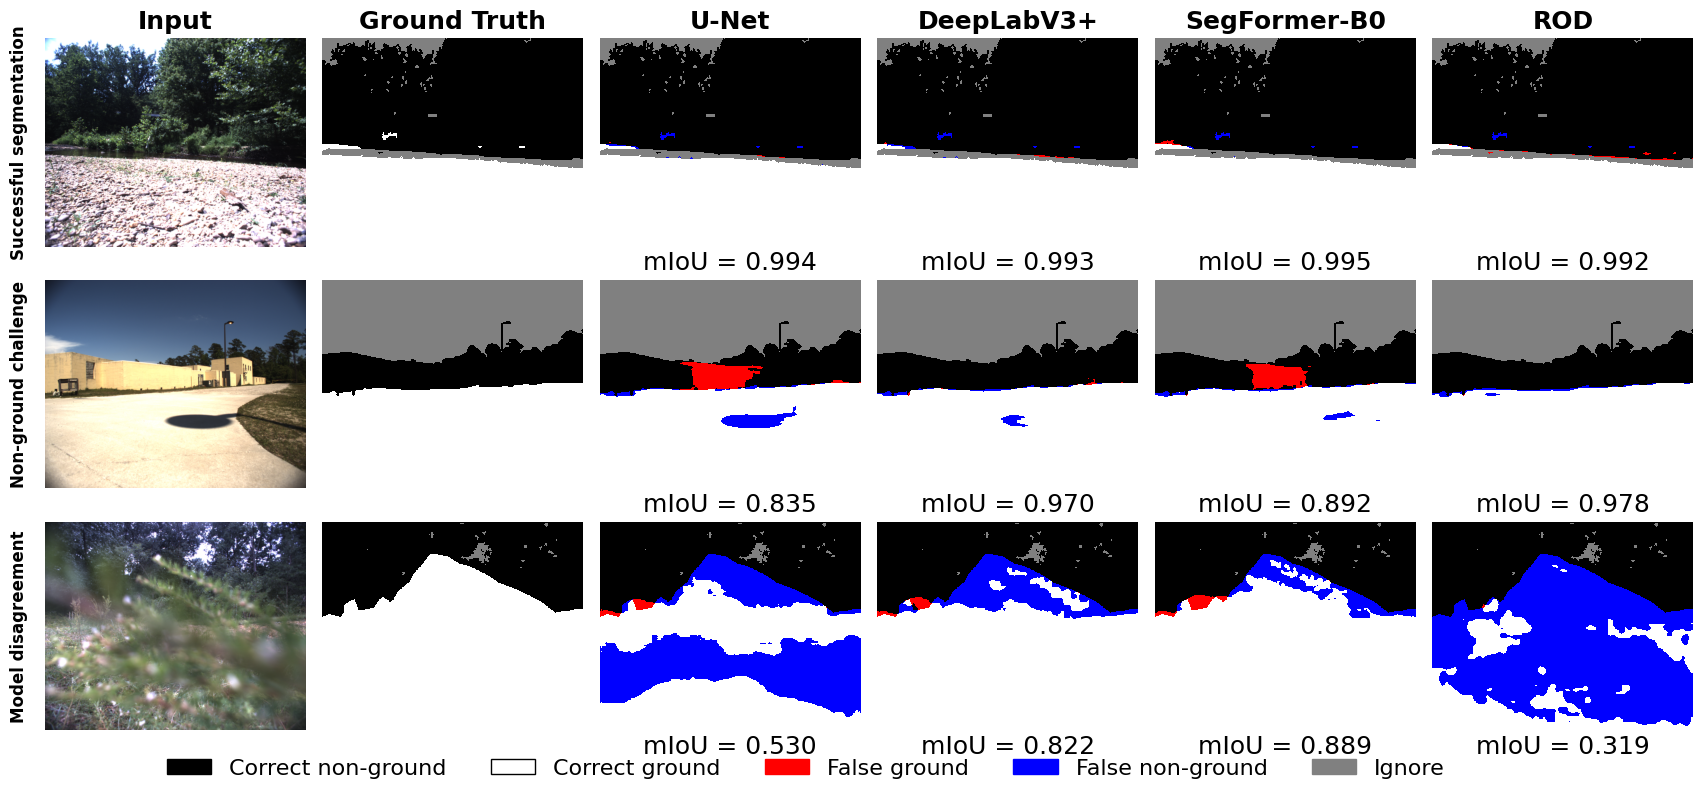

Saved final in-domain figure:
PNG: /content/drive/MyDrive/IRP/02_in_domain_rugd/qualitative_comparison/representative_cases_3x6/rugd_in_domain_representative_3x6_error_overlay.png
PDF: /content/drive/MyDrive/IRP/02_in_domain_rugd/qualitative_comparison/representative_cases_3x6/rugd_in_domain_representative_3x6_error_overlay.pdf


In [17]:
# ================================================================
# 16. Final 3 x 6 error-overlay figure
# ================================================================

from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch


MODEL_DISPLAY = [
    ("U-Net", "unet_miou"),
    ("DeepLabV3+", "deeplabv3plus_miou"),
    ("SegFormer-B0", "segformer_b0_miou"),
    ("ROD", "rod_miou"),
]


def load_saved_prediction(
    model_name: str,
    filename: str,
) -> np.ndarray:

    path = (
        PREDICTION_ROOT
        / model_name.replace("/", "_")
        / filename
    )

    if not path.exists():
        raise FileNotFoundError(
            path
        )

    return np.array(
        Image.open(path)
    ).astype(
        np.uint8
    )


def make_gt_display(
    gt: np.ndarray,
) -> np.ndarray:
    """
    Display values:
        0 = non-ground
        1 = ground
        2 = ignore
    """

    vis = np.full(
        gt.shape,
        2,
        dtype=np.uint8,
    )

    vis[
        gt == NON_GROUND_ID
    ] = 0

    vis[
        gt == GROUND_ID
    ] = 1

    return vis


def make_prediction_error_map(
    pred: np.ndarray,
    gt: np.ndarray,
) -> np.ndarray:
    """
    Display values:
        0 = correct non-ground
        1 = correct ground
        2 = false ground
            GT non-ground -> predicted ground
        3 = false non-ground
            GT ground -> predicted non-ground
        4 = ignore
    """

    vis = np.full(
        gt.shape,
        4,
        dtype=np.uint8,
    )

    valid = (
        gt
        != IGNORE_INDEX
    )

    vis[
        valid
        & (gt == NON_GROUND_ID)
        & (pred == NON_GROUND_ID)
    ] = 0

    vis[
        valid
        & (gt == GROUND_ID)
        & (pred == GROUND_ID)
    ] = 1

    # False ground
    vis[
        valid
        & (gt == NON_GROUND_ID)
        & (pred == GROUND_ID)
    ] = 2

    # False non-ground
    vis[
        valid
        & (gt == GROUND_ID)
        & (pred == NON_GROUND_ID)
    ] = 3

    return vis


def make_final_representative_figure(
    final_cases,
    save_dir,
    dpi=300,
):

    column_titles = [
        "Input",
        "Ground Truth",
        "U-Net",
        "DeepLabV3+",
        "SegFormer-B0",
        "ROD",
    ]

    gt_cmap = ListedColormap(
        [
            "black",
            "white",
            "gray",
        ]
    )

    error_cmap = ListedColormap(
        [
            "black",
            "white",
            "red",
            "blue",
            "gray",
        ]
    )

    n_rows = len(
        final_cases
    )

    fig, axes = plt.subplots(
        n_rows,
        6,
        figsize=(18, 8.0),
        squeeze=False,
    )

    for row_index, (_, record) in enumerate(
        final_cases.iterrows()
    ):

        # --------------------------------------------------------
        # RGB input
        # --------------------------------------------------------

        image = read_rgb(
            Path(
                record["image_path"]
            )
        )

        target_shape = image.shape[:2]

        # --------------------------------------------------------
        # Reconstruct verified binary GT from original RGB labels
        # --------------------------------------------------------

        semantic_rgb = read_rgb(
            Path(
                record["original_rgb_mask_path"]
            )
        )

        semantic_rgb = resize_nearest(
            semantic_rgb,
            target_shape,
        )

        gt = rugd_rgb_to_binary(
            semantic_rgb
        ).astype(
            np.uint8
        )

        # --------------------------------------------------------
        # Input
        # --------------------------------------------------------

        axes[
            row_index,
            0,
        ].imshow(
            image
        )

        # --------------------------------------------------------
        # Ground truth
        # --------------------------------------------------------

        gt_vis = make_gt_display(
            gt
        )

        axes[
            row_index,
            1,
        ].imshow(
            gt_vis,
            cmap=gt_cmap,
            vmin=0,
            vmax=2,
            interpolation="nearest",
        )

        # --------------------------------------------------------
        # Predictions + error overlay
        # --------------------------------------------------------

        for model_offset, (
            model_name,
            metric_col,
        ) in enumerate(
            MODEL_DISPLAY,
            start=2,
        ):

            pred = load_saved_prediction(
                model_name,
                record["processed_name"],
            )

            pred = resize_nearest(
                pred,
                target_shape,
            ).astype(
                np.uint8
            )

            error_map = make_prediction_error_map(
                pred,
                gt,
            )

            axes[
                row_index,
                model_offset,
            ].imshow(
                error_map,
                cmap=error_cmap,
                vmin=0,
                vmax=4,
                interpolation="nearest",
            )

            axes[
                row_index,
                model_offset,
            ].set_xlabel(
                f"mIoU = {record[metric_col]:.3f}",
                fontsize=18,
                labelpad=3,
            )

        # --------------------------------------------------------
        # Row label
        # --------------------------------------------------------

        axes[
            row_index,
            0,
        ].set_ylabel(
            record["case_label"],
            fontsize=12,
            rotation=90,
            labelpad=12,
            fontweight="bold",
        )

        # --------------------------------------------------------
        # Remove filenames, ticks and borders
        # --------------------------------------------------------

        axes[
            row_index,
            0,
        ].set_xlabel("")

        for col_index in range(6):

            axes[
                row_index,
                col_index,
            ].set_xticks([])

            axes[
                row_index,
                col_index,
            ].set_yticks([])

            for spine in axes[
                row_index,
                col_index,
            ].spines.values():
                spine.set_visible(
                    False
                )

    # ------------------------------------------------------------
    # Column titles
    # ------------------------------------------------------------

    for col_index, title in enumerate(
        column_titles
    ):

        axes[
            0,
            col_index,
        ].set_title(
            title,
            fontsize=18,
            fontweight="bold",
            pad=7,
        )

    # ------------------------------------------------------------
    # Legend
    # ------------------------------------------------------------

    legend_elements = [
        Patch(
            facecolor="black",
            edgecolor="black",
            label="Correct non-ground",
        ),
        Patch(
            facecolor="white",
            edgecolor="black",
            label="Correct ground",
        ),
        Patch(
            facecolor="red",
            edgecolor="red",
            label="False ground",
        ),
        Patch(
            facecolor="blue",
            edgecolor="blue",
            label="False non-ground",
        ),
        Patch(
            facecolor="gray",
            edgecolor="gray",
            label="Ignore",
        ),
    ]

    fig.legend(
        handles=legend_elements,
        loc="lower center",
        ncol=5,
        fontsize=16,
        frameon=False,
        bbox_to_anchor=(
            0.5,
            0.005,
        ),
    )

    # ------------------------------------------------------------
    # Layout
    # ------------------------------------------------------------

    fig.subplots_adjust(
        left=0.075,
        right=0.995,
        top=0.955,
        bottom=0.09,
        wspace=0.035,
        hspace=0.16,
    )

    # ------------------------------------------------------------
    # Save
    # ------------------------------------------------------------

    save_dir = Path(
        save_dir
    )

    save_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    png_path = (
        save_dir
        / "rugd_in_domain_representative_3x6_error_overlay.png"
    )

    pdf_path = (
        save_dir
        / "rugd_in_domain_representative_3x6_error_overlay.pdf"
    )

    fig.savefig(
        png_path,
        dpi=dpi,
        bbox_inches="tight",
        pad_inches=0.03,
    )

    fig.savefig(
        pdf_path,
        bbox_inches="tight",
        pad_inches=0.03,
    )

    plt.show()
    plt.close(
        fig
    )

    return (
        png_path,
        pdf_path,
    )


figure_png, figure_pdf = (
    make_final_representative_figure(
        final_cases=final_cases,
        save_dir=REPRESENTATIVE_DIR,
        dpi=300,
    )
)

print(
    "Saved final in-domain figure:"
)
print(
    "PNG:",
    figure_png,
)
print(
    "PDF:",
    figure_pdf,
)


## 17. Final selected-case summary

The CSV below records the exact three images used in the dissertation figure
and the relevant per-image metrics used for interpretation.


In [18]:
# ================================================================
# 17. Export selected-case summary
# ================================================================

summary_columns = [
    "case_label",
    "processed_name",
    "mean_model_miou",
    "average_non_ground_iou",
    "average_ground_iou",
    "rod_advantage",
    "unet_miou",
    "deeplabv3plus_miou",
    "segformer_b0_miou",
    "rod_miou",
]

selected_summary_df = final_cases[
    summary_columns
].copy()

SELECTED_SUMMARY_CSV = (
    REPRESENTATIVE_DIR
    / "selected_representative_cases_summary.csv"
)

selected_summary_df.to_csv(
    SELECTED_SUMMARY_CSV,
    index=False,
)

display(
    selected_summary_df
)

print(
    "Saved:",
    SELECTED_SUMMARY_CSV,
)


model,case_label,processed_name,mean_model_miou,average_non_ground_iou,average_ground_iou,rod_advantage,unet_miou,deeplabv3plus_miou,segformer_b0_miou,rod_miou
0,Successful segmentation,creek_creek_00811.png,0.993445,0.994168,0.992722,-0.001958,0.994413,0.992750,0.994641,0.991977
1,Non-ground challenge,village_village_00063.png,0.918650,0.881742,0.955558,0.078499,0.835363,0.970071,0.891642,0.977524
2,Model disagreement,trail-13_trail-13_00586.png,0.640009,0.633588,0.646429,-0.428161,0.530082,0.822437,0.888628,0.318888


Saved: /content/drive/MyDrive/IRP/02_in_domain_rugd/qualitative_comparison/representative_cases_3x6/selected_representative_cases_summary.csv


## Notes

This version preserves the verified ground-truth and inference pipeline from the
uploaded `v3_fixed_gt` notebook. Only the **case-selection logic** and
**qualitative display style** have been changed.

The recommended dissertation figure is:

`rugd_in_domain_representative_3x6_error_overlay.pdf`
